# Seleccion de Variables con Lasso


En el presente notebook se generan y se evalúan los siguientes modelos.

* Regresión lineal Lasso
* Regresión lineal
* Ridge
* Árbol de regresión
* KNN para regresión
* Regresión no paramétrica

El preprocesamiento principal se realiza mediante una seleccion de variables utilizando el metodo de regresion Lasso. 

In [1]:
library(pracma)
library(glmnet)
library("stats")
library("partykit")
library(ggplot2)
source("Utils.R")

Loading required package: Matrix

Attaching package: ‘Matrix’

The following objects are masked from ‘package:pracma’:

    expm, lu, tril, triu

Loading required package: foreach
Loaded glmnet 2.0-16

Loading required package: grid
Loading required package: libcoin
Loading required package: mvtnorm
Registered S3 methods overwritten by 'ggplot2':
  method         from 
  [.quosures     rlang
  c.quosures     rlang
  print.quosures rlang


In [2]:
library(reticulate)
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

StScaler <- import("sklearn.preprocessing", convert = FALSE)$StandardScaler
MMScaler <- import("sklearn.preprocessing", convert = FALSE)$MinMaxScaler

### Division de los datos

In [3]:
setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()

df <- vasijas_X
df$Y <- vasijas_Y


hold_out_ind <- obtener_holdout_ind(vasijas_X)

HOLDOUT_X <- vasijas_X[hold_out_ind, ]
HOLDOUT_Y <- vasijas_Y[hold_out_ind]
HOLDOUT_DF <- df[hold_out_ind, ]

TRAIN_Y <- vasijas_Y[-hold_out_ind]
TRAIN_X <- vasijas_X[-hold_out_ind, ]
TRAIN_DF <- df[-hold_out_ind, ]

# Seleccion de Variables con Lasso

### Modelo sin tuneo de parametros y sin escalar 

In [4]:
model <- glmnet(as.matrix(TRAIN_X), TRAIN_Y, alpha=1)

In [5]:
Y_pred = predict(model, as.matrix(TRAIN_X))
error_min <- sum((TRAIN_Y - Y_pred[, 1])^2) / nrow(TRAIN_X)
best_model <- 1
for (i in 2:ncol(Y_pred)) {
    curr_error <- sum((TRAIN_Y - Y_pred[, i])^2) / nrow(TRAIN_X)
    if (curr_error < error_min) {
        error_min <- curr_error 
        best_model <- i
    }
}
print(paste("El error cuadratico medio de train es: ", error_min, " usando el modelo numero: ", best_model))

[1] "El error cuadratico medio de train es:  0.694377895643682  usando el modelo numero:  100"


In [6]:
best_lambda = model$lambda[100]
print(paste("El lambda utilizado es: ", best_lambda))

[1] "El lambda utilizado es:  0.0372287988245699"


In [7]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
for(i in indices){

    X_train_scaled = X[-i,]
    Y_train = TRAIN_Y[-i]

    X_test_scaled = X[i,]
    Y_test = TRAIN_Y[i]

    model <- glmnet(as.matrix(X_train_scaled), Y_train, alpha=1, lambda = best_lambda)
    Y_pred = predict(model, as.matrix(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  1.26012561111025"


### Busqueda del mejor lambda

In [8]:
setSeed()
n = nrow(TRAIN_X)
k = 5
resultados <- data.frame(
  Lambda  =double(),
  Escalador = integer(),
  Error   =double()
)

indices = obtener_indices_kfold(n, k)
X <- TRAIN_X

lambdas <- logspace(-10, 3, 50)
alpha = 1
escaladores <- c(StScaler(), MMScaler())

for (lambda in lambdas) {
    for(s in 1:length(escaladores)){
        escalador = escaladores[[s]] 
        err = 0
        for (i in indices) {
            X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
            Y_train = TRAIN_Y[-i]

            X_test_scaled = as.matrix(escalador$transform(X[i, ]))
            Y_test = TRAIN_Y[i]

            model <- glmnet(X_train_scaled, Y_train, lambda=lambda, alpha=alpha)
            Y_pred = predict(model, X_test_scaled)
            err = err + sum((Y_test - Y_pred)^2)
        }
        resultados = rbind(resultados, list(lambda,s,  err/n))
    }
    message(progreso(lambda, lambdas))
}

colnames(resultados)  <- c("lambda", "Escalador", "Error")

El progreso es del 2 %
El progreso es del 4 %
El progreso es del 6 %
El progreso es del 8 %
El progreso es del 10 %
El progreso es del 12 %
El progreso es del 14 %
El progreso es del 16 %
El progreso es del 18 %
El progreso es del 20 %
El progreso es del 22 %
El progreso es del 24 %
El progreso es del 26 %
El progreso es del 28 %
El progreso es del 30 %
El progreso es del 32 %
El progreso es del 34 %
El progreso es del 36 %
El progreso es del 38 %
El progreso es del 40 %
El progreso es del 42 %
El progreso es del 44 %
El progreso es del 46 %
El progreso es del 48 %
El progreso es del 50 %
El progreso es del 52 %
El progreso es del 54 %
El progreso es del 56 %
El progreso es del 58 %
El progreso es del 60 %
El progreso es del 62 %
El progreso es del 64 %
El progreso es del 66 %
El progreso es del 68 %
El progreso es del 70 %
El progreso es del 72 %
El progreso es del 74 %
El progreso es del 76 %
El progreso es del 78 %
El progreso es del 80 %
El progreso es del 82 %
El progreso es del 8

Los mejores parámetros obtenidos fueron entonces:

In [9]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,lambda,Escalador,Error
62,0.009102982,2,0.9994413


### Calculo del error por LOOCV

In [10]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
escalador = escaladores[[mejores_parametros$Escalador]]
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- glmnet(X_train_scaled, Y_train, lambda=mejores_parametros$lambda, alpha=1)
    Y_pred = predict(model, X_test_scaled)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.844437940474485"


Vemos que el error de LOOCV dio menor

In [11]:
X_scaled <- as.matrix(escalador$fit_transform(TRAIN_X))
modelo1 <- glmnet(X_scaled, TRAIN_Y, alpha=1, lambda=mejores_parametros$lambda)

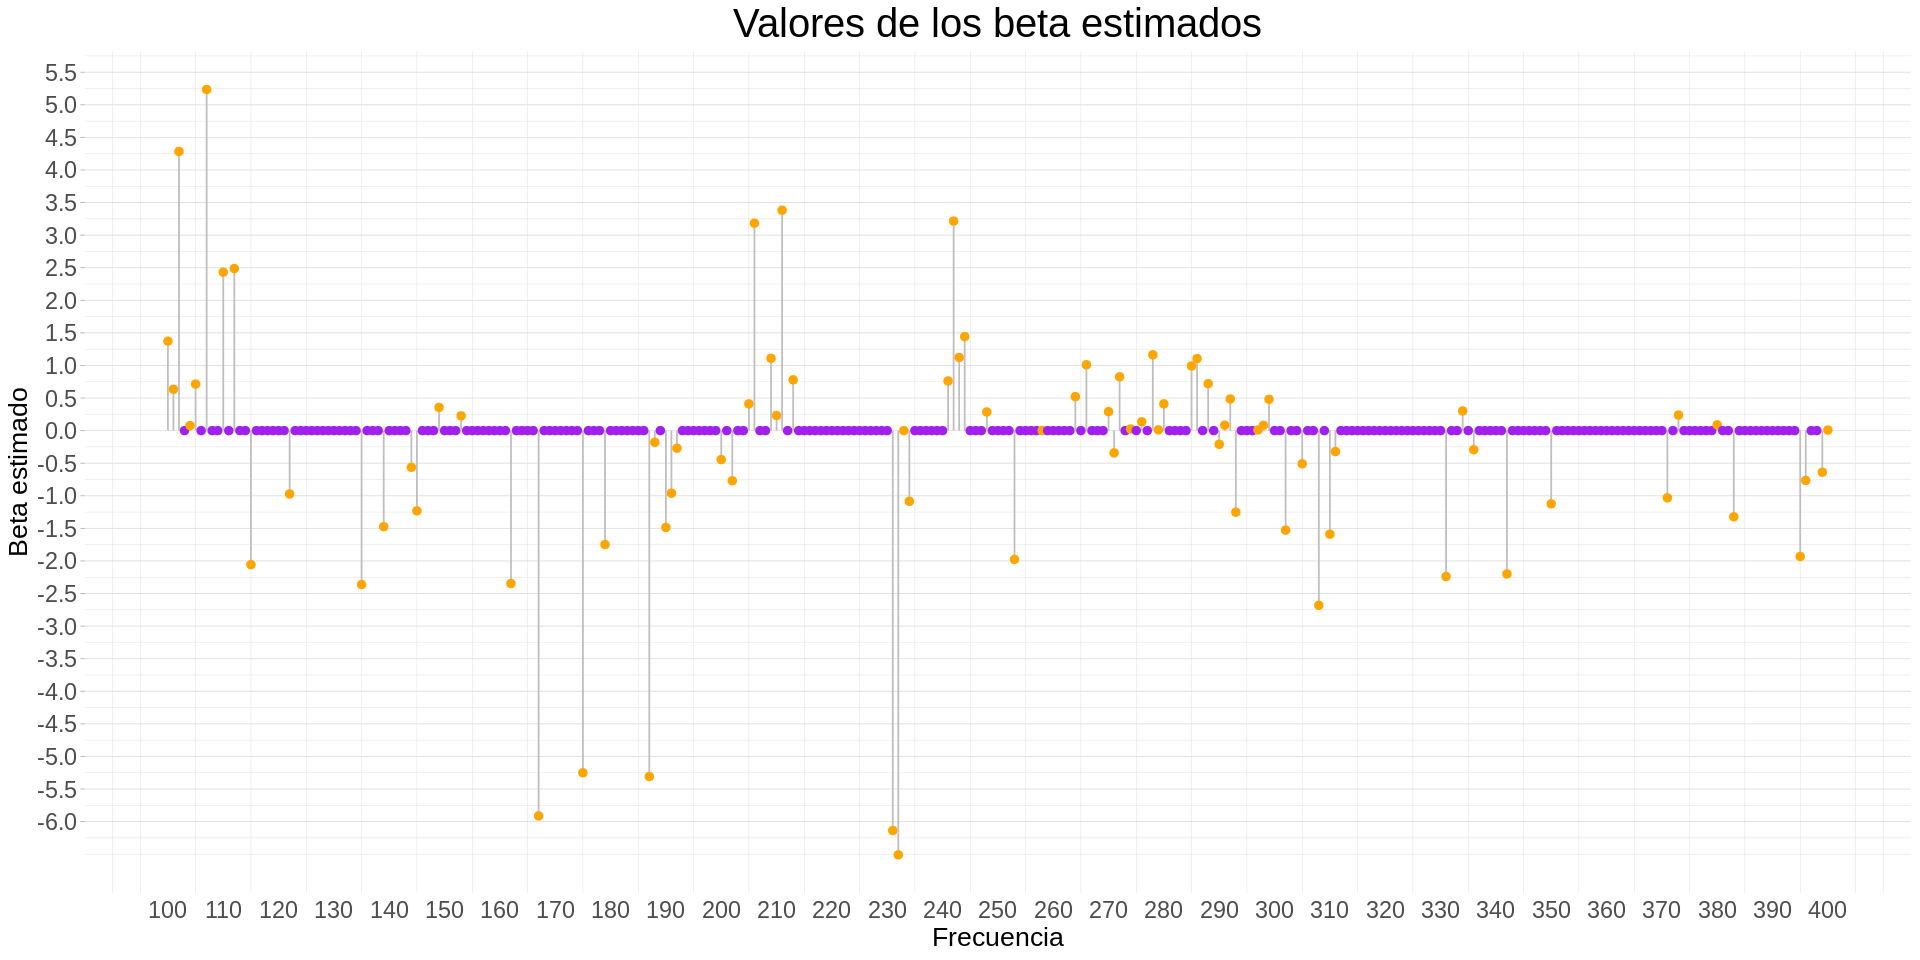

In [15]:
x_plot = as.integer(sub('.', '', colnames(TRAIN_X))) + 99

data_plot <- data.frame(
  x=x_plot,
  y=modelo1$beta[,1]
)


# Plot

options(repr.plot.width=16, repr.plot.height=8)

colores = sapply(modelo1$beta[,1], function(x) (ifelse(x!=0, "orange",  "purple")))
ggplot(data_plot, aes(x=x, y=y)) +
  ggtitle("Valores de los beta estimados") +
  geom_segment( aes(x=x, xend=x, y=0, yend=y), color="grey") +
  geom_point(color=colores, size=2) +
  theme_light() +
  theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank()) +
  scale_x_continuous(breaks = seq(100, 400, by=10)) +
  scale_y_continuous(breaks = seq(-6, 6, by=0.5)) +
  xlab("Frecuencia") + ylab("Beta estimado")

In [19]:
variables_to_filter = modelo1$beta[,1] != 0
print(paste("El mejor modelo de Lasso encontrado elimino ", sum(modelo1$beta[,1] == 0), " variables"))
print(paste("El mejor modelo de Lasso encontrado se quedo con ", sum(modelo1$beta[,1] != 0), " variables"))

[1] "El mejor modelo de Lasso encontrado elimino  219  variables"
[1] "El mejor modelo de Lasso encontrado se quedo con  82  variables"


In [18]:
p = sum(modelo1$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.901434639417397"


In [17]:
SELECTED_TRAIN_X <- TRAIN_X[, variables_to_filter]
SELECTED_TRAIN_DF <- SELECTED_TRAIN_X
SELECTED_TRAIN_DF$Y <- TRAIN_Y

SELECTED_HOLDOUT_X <- HOLDOUT_X[, variables_to_filter]
SELECTED_HOLDOUT_DF <- SELECTED_HOLDOUT_X
SELECTED_HOLDOUT_DF$Y <- HOLDOUT_Y

# Modelo 2: Regresion Lineal

In [20]:
# No escalamos los datos porque no hay regularizacion.

model <- lm(Y~., data = SELECTED_TRAIN_DF)

Y_pred = predict(model, SELECTED_TRAIN_X)
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(SELECTED_TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

[1] "El error cuadratico medio de train es:  0.101794159667565"


In [21]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){
    df_train = X[-i,]
    df_train$Y = TRAIN_Y[-i]
    
    X_test = X[i,]
    Y_test = TRAIN_Y[i]

    model <- lm(Y~.,  data = df_train)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.4556017240322"


In [30]:
p = sum(modelo1$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.987359477755938"


# Modelo 3: Regresion Lineal Regularizada

### Sólo iterando lambda y sin escalar

In [32]:
model <- glmnet(as.matrix(SELECTED_TRAIN_X), TRAIN_Y)

In [33]:
Y_pred = predict(model, as.matrix(SELECTED_TRAIN_X))
error_min <- sum((TRAIN_Y - Y_pred[, 1])^2) / nrow(SELECTED_TRAIN_X)
best_model <- 1
for (i in 2:ncol(Y_pred)) {
    curr_error <- sum((TRAIN_Y - Y_pred[, i])^2) / nrow(SELECTED_TRAIN_X)
    if (curr_error < error_min) {
        error_min <- curr_error 
        best_model <- i
    }
}
print(paste("El error cuadratico medio de train es: ", error_min, " usando el modelo numero: ", best_model))

[1] "El error cuadratico medio de train es:  0.104858837471819  usando el modelo numero:  96"


In [34]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){

    X_train_scaled = X[-i,]
    Y_train = TRAIN_Y[-i]

    X_test_scaled = X[i,]
    Y_test = TRAIN_Y[i]

    model <- glmnet(as.matrix(X_train_scaled), Y_train, lambda=0.0372, alpha=1)
    Y_pred = predict(model, as.matrix(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  1.15218857472908"


### Busqueda de los parametros de la prediccion

In [37]:
setSeed()
n = nrow(SELECTED_TRAIN_X)
k = 5
resultados <- data.frame(
  Alpha   =double(),
  Lambda  =double(),
  Escalador = integer(),
  Error   =double()
)

indices = obtener_indices_kfold(n, k)
X <- SELECTED_TRAIN_X

alphas <- seq(0, 1, 0.05)
lambdas <- logspace(-10, 3, 50)
escaladores <- c(StScaler(), MMScaler())


for (alpha in alphas) {
    for (lambda in lambdas) {
        for(s in 1:length(escaladores)){
            escalador = escaladores[[s]] 
            err = 0
            for (i in indices) {
                X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
                Y_train = TRAIN_Y[-i]

                X_test_scaled = as.matrix(escalador$transform(X[i, ]))
                Y_test = TRAIN_Y[i]

                model <- glmnet(X_train_scaled, Y_train, lambda=lambda, alpha=alpha)
                Y_pred = predict(model, X_test_scaled)
                err = err + sum((Y_test - Y_pred)^2)
            }
            resultados = rbind(resultados, list(alpha, lambda, s, err/n))
        }
    }
    message(progreso(alpha, alphas))
}

colnames(resultados)  <- c("alpha", "lambda", "Escalador", "Error")

El progreso es del 4.8 %
El progreso es del 9.5 %
El progreso es del 14.3 %
El progreso es del 19 %
El progreso es del 23.8 %
El progreso es del 28.6 %
El progreso es del 33.3 %
El progreso es del 38.1 %
El progreso es del 42.9 %
El progreso es del 47.6 %
El progreso es del 52.4 %
El progreso es del 57.1 %
El progreso es del 61.9 %
El progreso es del 66.7 %
El progreso es del 71.4 %
El progreso es del 76.2 %
El progreso es del 81 %
El progreso es del 85.7 %
El progreso es del 90.5 %
El progreso es del 95.2 %
El progreso es del 100 %


Los mejores parámetros obtenidos fueron entonces:

In [38]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,alpha,lambda,Escalador,Error
64,0,0.01676833,2,0.3543098


### Calculo del error por LOOCV

In [39]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
escalador = escaladores[[mejores_parametros$Escalador]]
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- glmnet(X_train_scaled, Y_train, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)
    Y_pred = predict(model, X_test_scaled)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.355068189588116"


In [41]:
X_train_scaled <- as.matrix(escalador$fit_transform(X))
modelo3 <- glmnet(X_train_scaled, TRAIN_Y, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)

p = sum(modelo3$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.958555362732162"


In [42]:
p

[1] 82

No elimino ninguno

# Modelo 4: árbol de regresión

### Sin tuneo de parametros

In [44]:
Y_pred = predict(model, SELECTED_TRAIN_X)
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(SELECTED_TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){
    df_train = X[-i,]
    df_train$Y = TRAIN_Y[-i]
    
    X_test = X[i,]
    Y_test = TRAIN_Y[i]

    model <- ctree(Y ~ ., data = df_train)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio de train es:  1.35253236475579"
[1] "El error cuadratico medio con LOOCV de train es:  2.57561865526944"


### Busqueda de los parametros de la prediccion

In [48]:
library(rpart)
library(rpart.plot)

In [50]:
setSeed()

n = nrow(SELECTED_TRAIN_X)
k = 10

resultados <- data.frame(
  Minsplit =double(),
  Maxdepth =double(),
  CP       =double(),
  Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- SELECTED_TRAIN_X

minsplits <- c(2, 5, 10, 20, 30, 50)

for (minsplit in minsplits) {
    for (maxdepth in c(4, 5, 6, 7, 8)) {
        for (cp in c(0.0005, 0.001, 0.005, 0.01, 0.015, 0.025)) {
            parametros = rpart.control(minsplit=minsplit, maxdepth=maxdepth, cp=cp)
            err = 0
            for(i in indices) {
                DF_train = X[-i,]
                DF_train$Y = TRAIN_Y[-i]

                DF_test = X[i,]
                DF_test$Y = TRAIN_Y[i]
                
                model <- rpart(Y ~ ., data = DF_train, control=parametros, xval=1)
                Y_pred = predict(model, DF_test)
                err = err + sum((DF_test$Y - Y_pred)^2)
            }
            resultados = rbind(resultados, list(minsplit, maxdepth, cp, err/n))
        }
    }
    message(progreso(minsplit, minsplits))
}

colnames(resultados)  <- c("Minsplit", "Maxdepth", "CP", "Error")

El progreso es del 16.7 %
El progreso es del 33.3 %
El progreso es del 50 %
El progreso es del 66.7 %
El progreso es del 83.3 %
El progreso es del 100 %


In [51]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,Minsplit,Maxdepth,CP,Error
61,10,4,5e-04,1.836139


### Calculo del error

In [55]:
parametros <- rpart.control(minsplit=mejores_parametros$Minsplit, maxdepth=mejores_parametros$Maxdepth, cp=mejores_parametros$CP)

modelo4 <- rpart(Y ~ ., data = SELECTED_TRAIN_DF, control=parametros)

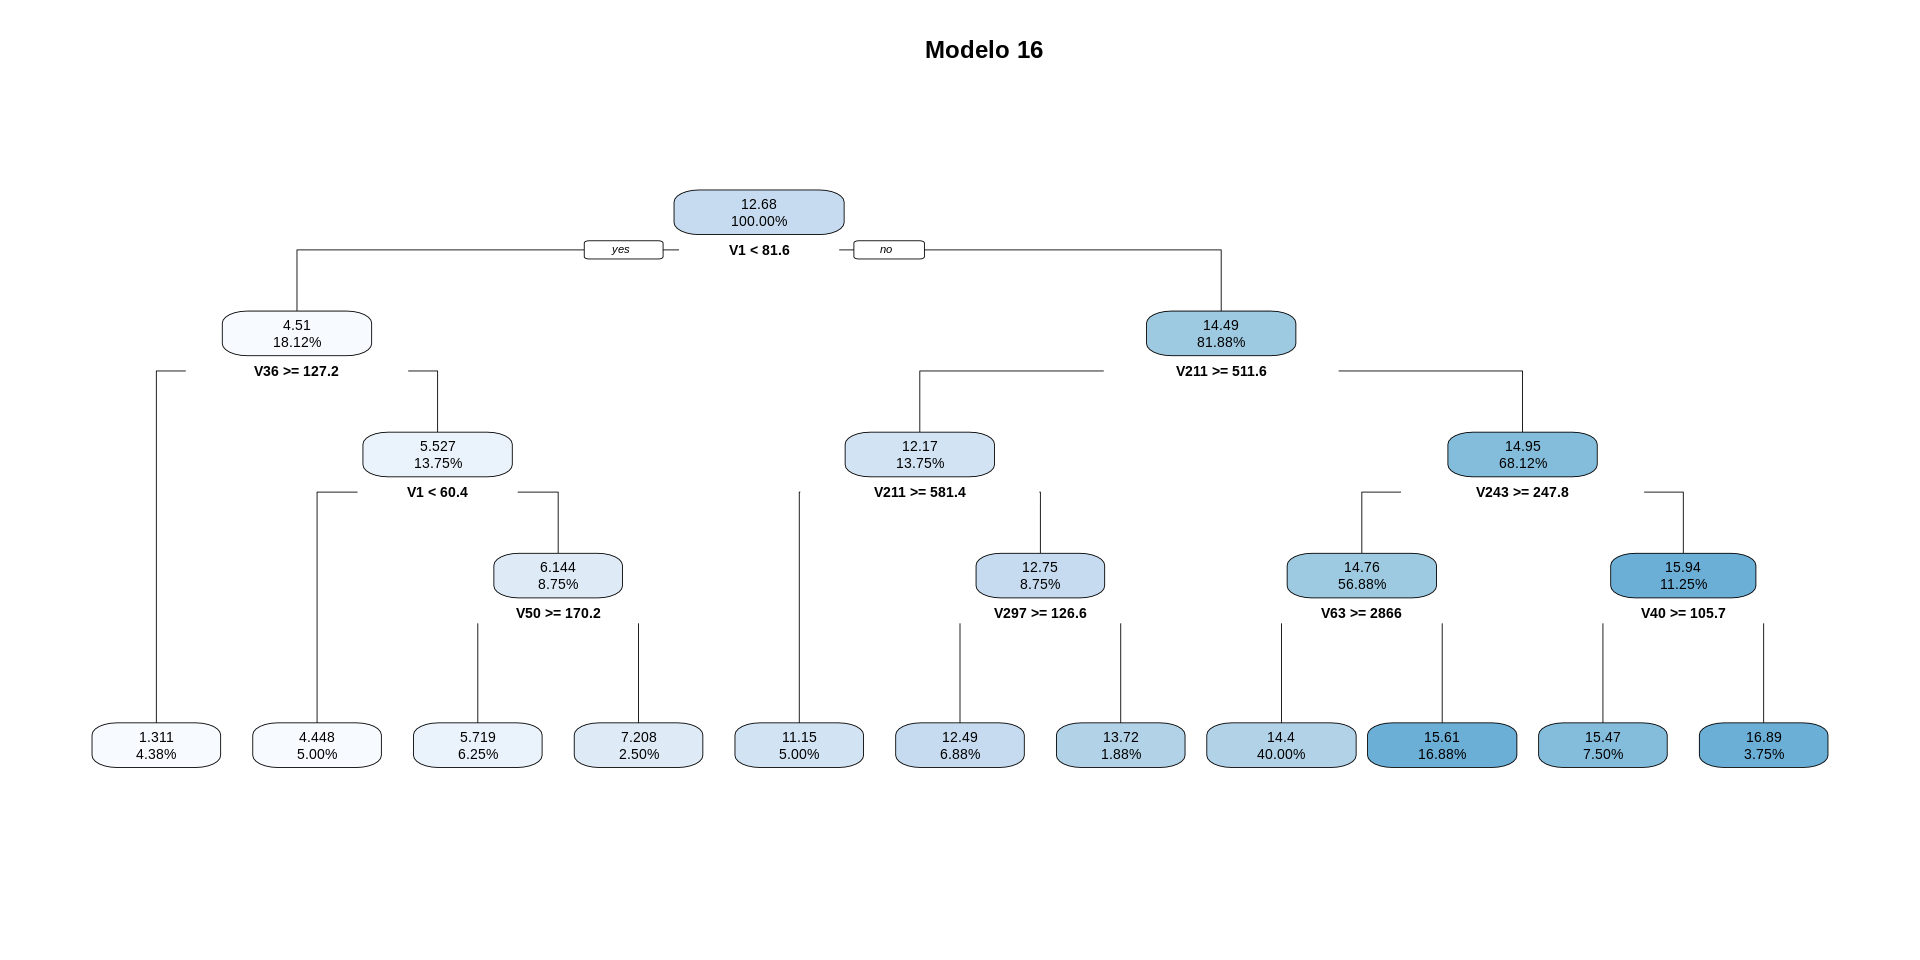

In [53]:
rpart.plot(modelo2, digits=4)
title("Modelo 16")

In [54]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){
    train_df <- X[-i,]
    train_df$Y <- TRAIN_Y[-i]
    X_test <- X[i,]
    Y_test = TRAIN_Y[i]

    model <- rpart(Y ~ ., data = train_df, control=parametros)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  1.44432645194591"


In [56]:
p = 8
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.913488676317414"


# Modelo 5: KNN para regresión

In [57]:
library(reticulate)

In [58]:
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

In [59]:
knnr <- import("sklearn.neighbors", convert = FALSE)$KNeighborsRegressor

### Sin tuneo de parametros

In [60]:
model <- knnr()$fit(SELECTED_TRAIN_X, TRAIN_Y)

In [61]:
Y_pred = as.double(model$predict(SELECTED_TRAIN_X))
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(SELECTED_TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

[1] "El error cuadratico medio de train es:  0.72084916375"


### Busqueda de los parametros de la prediccion

In [62]:
setSeed()

n = nrow(SELECTED_TRAIN_X)
k = 10

resultados <- data.frame(
    K        =integer(),
    Weights  =integer(),
    p        =integer(),
    S        =integer(),
    Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- SELECTED_TRAIN_X
escaladores <- c(StScaler(), MMScaler())
for(K in 1:10){
    for(w in c(1, 2)){
        wei = ifelse(w==1, "uniform", "distance")
        for(p in c(1, 2)){
            for(s in 1:length(escaladores)){
                escalador = escaladores[[s]]
                err = 0
                for(i in indices){
                    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
                    Y_train = TRAIN_Y[-i]

                    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
                    Y_test = TRAIN_Y[i]
                    
                    model <- knnr(n_neighbors=K, p=p, weights=wei)$fit(X_train_scaled, Y_train)
                    Y_pred = as.double(model$predict(X_test_scaled))
                    err = err + sum((Y_test - Y_pred)^2)
                }
                resultados = rbind(resultados, list(K, w, p, s, err/n))
            }
        }
    }
    message(progreso(K, 1:10))
}
colnames(resultados)  <- c("K", "Weights", "Distance", "Escalador", "Error")

El progreso es del 10 %
El progreso es del 20 %
El progreso es del 30 %
El progreso es del 40 %
El progreso es del 50 %
El progreso es del 60 %
El progreso es del 70 %
El progreso es del 80 %
El progreso es del 90 %
El progreso es del 100 %


In [63]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,K,Weights,Distance,Escalador,Error
22,3,2,1,2,0.826318


### Calculo del error

In [64]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
escalador = escaladores[[mejores_parametros$Escalador]]
wei <- ifelse(mejores_parametros$Weights==1, "uniform", "distance")
err = 0
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$Distance, weights=wei)$fit(X_train_scaled, Y_train)
    Y_pred = as.double(model$predict(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.782500216891657"


In [65]:
p = 82
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
hatY

[1] 0.9086642

# Modelo 6: regresión no paramétrica

$$\hat{m}_{h}(x) = \frac{\sum^{n}_{i=1} K(\frac{x-x_i}{h}) y_i}{\sum^{n}_{i=1}K(\frac{x-x_i}{h})} = \sum^{n}_{i=1} w_i(x) y_i$$

In [66]:
D <- function(x, y) (sum((abs(x-y))))
calc <- function(X, Y, h, K, x0){
    wis <- apply(X, 1, function(xi) (K(D(xi, x0)/h)))
    return(sum(wis*Y)/sum(wis))
}
npr <- function(x, X, Y, h, K){
    return(apply(x, 1, function(x0) (calc(X, Y, h, K, x0))))
}

In [72]:
setSeed()

n = nrow(SELECTED_TRAIN_X)
k = 10

indices = obtener_indices_kfold(n, k)
X <- SELECTED_TRAIN_X

resultados <- data.frame(
    h       =double(),
    K       =integer(),
    Error   =double()
)
escalador = StScaler()

hs = seq(0.1, 15, l=30)
Ks = list((function(x) (0.5 * (abs(x)<1))),
          (function(x) (dnorm(x))),
          (function(x) (0.75*(1-x^2)*(abs(x)<1))),
          (function(x) ((15/16)*((1-x^2)^2)*(abs(x)<1)))
       )

for(h in hs){
    for(Knumber in 1:length(Ks)){
        K = Ks[[Knumber]]
        err = 0
        for(i in indices){
            X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
            Y_train = TRAIN_Y[-i]

            X_test_scaled = as.matrix(escalador$transform(X[i, ]))
            Y_test = TRAIN_Y[i]
            
            Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, h, K)
            err = err + sum((Y_test - Y_pred)^2)
        }
        resultados = rbind(resultados, list(h, Knumber, err/n))
    }
    message(progreso(h, hs))
}
colnames(resultados)  <- c("h", "K", "Error")

El progreso es del 3.3 %
El progreso es del 6.7 %
El progreso es del 10 %
El progreso es del 13.3 %
El progreso es del 16.7 %
El progreso es del 20 %
El progreso es del 23.3 %
El progreso es del 26.7 %
El progreso es del 30 %
El progreso es del 33.3 %
El progreso es del 36.7 %
El progreso es del 40 %
El progreso es del 43.3 %
El progreso es del 46.7 %
El progreso es del 50 %
El progreso es del 53.3 %
El progreso es del 56.7 %
El progreso es del 60 %
El progreso es del 63.3 %
El progreso es del 66.7 %
El progreso es del 70 %
El progreso es del 73.3 %
El progreso es del 76.7 %
El progreso es del 80 %
El progreso es del 83.3 %
El progreso es del 86.7 %
El progreso es del 90 %
El progreso es del 93.3 %
El progreso es del 96.7 %
El progreso es del 100 %


In [73]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,h,K,Error
66,8.32069,2,0.8576987


In [76]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
escalador = StScaler()
K = Ks[[mejores_parametros$K]]
err = 0
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, mejores_parametros$h, K)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.816390522527997"


In [77]:
p = 82
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
hatY

[1] 0.9047084